In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os
import sys

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

In [3]:
from src.config import *
from src.environment import HotelPricingEnv
from src.dqn_agent import DQNAgent

In [4]:
env = HotelPricingEnv()
agent = DQNAgent(state_size=2,action_size=len(PRICE_LEVELS))
print("Environment and DQN Agent initialized successfully.")
print(agent)

Environment and DQN Agent initialized successfully.


In [5]:
state, info = env.reset()
print(state)

[50 30]


In [6]:
action = agent.select_action(state)

print("Action Index: ",action)
print("Selected Price: ",PRICE_LEVELS[action])

Action Index:  4
Selected Price:  160


In [7]:
next_state, reward, done, _, info = env.step(action)

print("Next State: ", next_state)
print("Reward: ", reward)
print("Done: ", done)

Next State:  [50 29]
Reward:  0
Done:  False


In [8]:
agent.remember(state,action,reward,next_state,done)

print("Replay Buffer Size")
print(len(agent.memory))

Replay Buffer Size
1


In [9]:
print("Collecting Experiences...\n")

episodes = 100

for episode in range(episodes):
    state, info = env.reset()
    done = False

    while not done:
        action = agent.select_action(state)
        next_state, reward, done, _, info = env.step(action)
        agent.remember(state,action,reward,next_state,done)
        state = next_state

print(f"Replay Buffer Size : {len(agent.memory)}")


Replay Buffer Size : 2998


In [10]:
loss_history = []
epochs = 500

print("Training Started...\n")

for epoch in range(epochs):
    loss = agent.train()
    if loss is not None:
        loss_history.append(loss)
    if (epoch + 1) % 20 == 0:
        agent.update_target_network()

print("Training Completed.")

Training Started...

Training Completed.


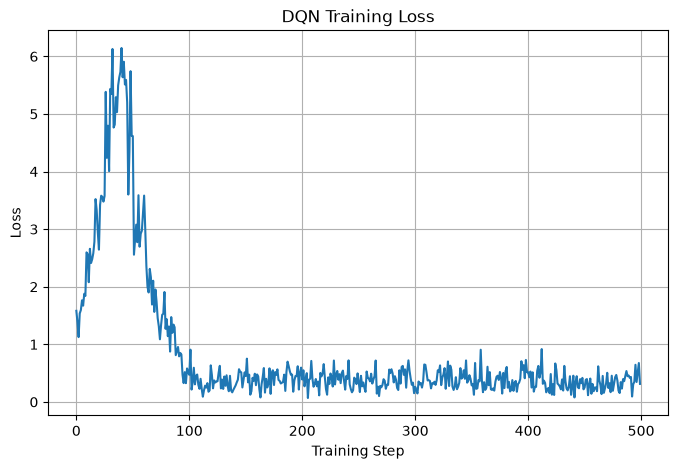

In [11]:
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.title("DQN Training Loss")

plt.xlabel("Training Step")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

In [12]:
print(f"Minimum Loss : {min(loss_history):.4f}")
print(f"Maximum Loss : {max(loss_history):.4f}")
print(f"Average Loss : {np.mean(loss_history):.4f}")
print(f"Final Loss   : {loss_history[-1]:.4f}")

Minimum Loss : 0.0681
Maximum Loss : 6.1452
Average Loss : 0.8517
Final Loss   : 0.3128


In [13]:
agent.epsilon = 0
episodes = 20
results = []
episode_rewards = []

for episode in range(episodes):
    state, info = env.reset()
    done = False

    total_reward = 0
    total_price = 0
    total_rooms = 0
    total_days = 0

    while not done:
        action = agent.select_action(state)
        price = PRICE_LEVELS[action]
        next_state, reward, done, _, info = env.step(action)

        total_reward += reward
        total_price += price
        total_rooms += info["rooms_sold"]
        total_days += 1

        state = next_state

    occupancy = (total_rooms / TOTAL_ROOMS) * 100
    episode_rewards.append(total_reward)

    results.append({
        "Revenue": total_reward,
        "Rooms Sold": total_rooms,
        "Occupancy": occupancy,
        "Average Price": total_price / total_days
    })

In [14]:
import pandas as pd

results = pd.DataFrame(results)
results

,Revenue,Rooms Sold,Occupancy,Average Price
0,3640,32,64.0,146.666667
1,2880,24,48.0,146.666667
2,2575,21,42.0,147.333333
3,3035,25,50.0,146.000000
4,3205,27,54.0,146.000000
5,2915,25,50.0,145.333333
6,4260,36,72.0,144.000000
7,3150,26,52.0,146.000000
8,3125,27,54.0,146.000000
9,2730,22,44.0,147.333333


In [15]:
summary = pd.DataFrame({
    "Metric":["Average Revenue",
              "Average Rooms Sold",
              "Average Occupancy (%)",
              "Average Price"],
    "Value":[results["Revenue"].mean(),
             results["Rooms Sold"].mean(),
             results["Occupancy"].mean(),
             results["Average Price"].mean()]
})
summary

,Metric,Value
0,Average Revenue,3232.500000
1,Average Rooms Sold,26.900000
2,Average Occupancy (%),53.800000
3,Average Price,146.233333
